##**DATA PREPARATION**

In [1]:
import os
import shutil
import zipfile
from tqdm import tqdm
from PIL import Image
import numpy as np

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']

# Paths for hijabi and non-hijabi image storage
DRIVE_HIJABI_PATH = '/content/drive/MyDrive/Emotion_hijabi'
LOCAL_HIJABI_PATH = '/content/data/raw/hijabi'
LOCAL_NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

TARGET_PER_EMOTION = 500

def copy_hijabi_from_drive():
    # Copy images from Drive if not already copied
    if not os.path.exists(DRIVE_HIJABI_PATH):
        return False

    for emotion in EMOTIONS:
        src_dir = os.path.join(DRIVE_HIJABI_PATH, emotion)
        dst_dir = os.path.join(LOCAL_HIJABI_PATH, emotion)
        os.makedirs(dst_dir, exist_ok=True)

        if not os.path.exists(src_dir):
            continue

        images = [img for img in os.listdir(src_dir)
                 if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img in images:
            src_path = os.path.join(src_dir, img)
            dst_path = os.path.join(dst_dir, img)
            if not os.path.exists(dst_path):
                try:
                    shutil.copy2(src_path, dst_path)
                except:
                    continue
    return True

def upload_non_hijabi():
    # Upload and extract zip for non-hijabi dataset
    from google.colab import files as colab_files
    uploaded = colab_files.upload()
    if not uploaded:
        return False

    zip_filename = list(uploaded.keys())[0]
    temp_dir = '/content/non_hijabi_temp'

    try:
        with zipfile.ZipFile(zip_filename, 'r') as z:
            z.extractall(temp_dir)
    except:
        return False

    # RAF-DB folder mapping for emotion labels
    RAF_EMOTION_MAP = {'1':'surprise', '4':'happy', '5':'sad', '6':'angry', '7':'neutral'}

    train_path = None
    test_path = None

    for root, dirs, _ in os.walk(temp_dir):
        if 'train' in dirs and train_path is None:
            train_path = os.path.join(root, 'train')
        if 'test' in dirs and test_path is None:
            test_path = os.path.join(root, 'test')

    is_rafdb = train_path and os.path.exists(train_path) and any(d in ['1','4','5','6','7'] for d in os.listdir(train_path))

    total_copied = 0

    if is_rafdb:
        # Process RAF-DB images per emotion
        images_by_emotion = {emotion: [] for emotion in EMOTIONS}
        for folder_type in [train_path, test_path]:
            if not folder_type or not os.path.exists(folder_type):
                continue
            for emotion_id, emotion_name in RAF_EMOTION_MAP.items():
                folder = os.path.join(folder_type, emotion_id)
                if os.path.exists(folder):
                    imgs = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                    images_by_emotion[emotion_name].extend(imgs)

        import random
        random.seed(42)

        for emotion in EMOTIONS:
            dst_folder = os.path.join(LOCAL_NON_HIJABI_PATH, emotion)
            os.makedirs(dst_folder, exist_ok=True)
            available = images_by_emotion[emotion]
            selected = random.sample(available, min(TARGET_PER_EMOTION, len(available)))

            for i, src_path in enumerate(selected):
                dst_path = os.path.join(dst_folder, f"nh_{emotion}_{i:04d}.jpg")
                try:
                    img = Image.open(src_path)
                    if img.mode != 'RGB': img = img.convert('RGB')
                    img.resize((224,224), Image.BILINEAR).save(dst_path, 'JPEG', quality=95)
                    total_copied += 1
                except:
                    continue

    else:
        # Process a regular dataset with emotion folders
        emotion_folders = {}
        for root, dirs, _ in os.walk(temp_dir):
            for emotion in EMOTIONS:
                for d in dirs:
                    if d.lower() == emotion.lower():
                        emotion_folders[emotion] = os.path.join(root, d)
                        break
            if len(emotion_folders) == len(EMOTIONS):
                break

        if len(emotion_folders) < len(EMOTIONS):
            return False

        for emotion in EMOTIONS:
            src_folder = emotion_folders[emotion]
            dst_folder = os.path.join(LOCAL_NON_HIJABI_PATH, emotion)
            os.makedirs(dst_folder, exist_ok=True)

            images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
            for i, img_name in enumerate(images[:TARGET_PER_EMOTION]):
                try:
                    img = Image.open(os.path.join(src_folder, img_name))
                    if img.mode != 'RGB': img = img.convert('RGB')
                    img.resize((224,224), Image.BILINEAR).save(os.path.join(dst_folder, f"nh_{emotion}_{i:04d}.jpg"), 'JPEG', quality=95)
                    total_copied += 1
                except:
                    continue

    shutil.rmtree(temp_dir, ignore_errors=True)
    try: os.remove(zip_filename)
    except: pass


    return True

def verify_final_dataset():
    # Check balance and minimum image count per emotion
    total_hijabi = 0
    total_non_hijabi = 0
    all_balanced = True

    for emotion in EMOTIONS:
        h_dir = os.path.join(LOCAL_HIJABI_PATH, emotion)
        nh_dir = os.path.join(LOCAL_NON_HIJABI_PATH, emotion)

        h_count = len([f for f in os.listdir(h_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(h_dir) else 0
        nh_count = len([f for f in os.listdir(nh_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(nh_dir) else 0

        total_hijabi += h_count
        total_non_hijabi += nh_count

        if h_count < 200 or nh_count < 200 or abs(h_count - nh_count) > 50:
            all_balanced = False

    return all_balanced, total_hijabi, total_non_hijabi

def main():
    # Run dataset preparation pipeline
    copy_hijabi_from_drive()
    if not upload_non_hijabi():
        return
    balanced, h, nh = verify_final_dataset()

    print("Pipeline finished.")

if __name__ == "__main__":
    main()


Mounted at /content/drive


Saving non_hijab_data.zip to non_hijab_data.zip
Pipeline finished.


In [2]:
# from PIL import ImageFile
# ImageFile.LOAD_TRUNCATED_IMAGES = True
# import warnings
# warnings.filterwarnings('ignore')

# import os
# import numpy as np
# import pandas as pd
# from PIL import Image
# from collections import Counter
# import matplotlib.pyplot as plt
# import seaborn as sns

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms as transforms
# import torchvision.models as models

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
#                             confusion_matrix, classification_report)
# from tqdm import tqdm


# EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
# EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

# HIJABI_PATH = '/content/data/raw/hijabi'
# NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

# IMG_SIZE = 224
# BATCH_SIZE = 32
# NUM_EPOCHS = 30
# LEARNING_RATE = 1e-3

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# # 1. Dataset Class (FIXED)
# class EmotionDataset(Dataset):
#     # Load image or return black if corrupted
#     def __init__(self, image_paths, emotions, hijab_labels, transform=None):
#         self.image_paths = image_paths
#         self.emotions = emotions
#         self.hijab_labels = hijab_labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):

#         img_path = self.image_paths[idx]

#         try:
#             img = Image.open(img_path).convert('RGB')
#         except Exception as e:
#             print(f" Corrupted image: {img_path}")
#             img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

#         # Transform
#         if self.transform:
#             img = self.transform(img)

#         emotion = self.emotions[idx]
#         hijab = self.hijab_labels[idx]

#         return {
#             'image': img,
#             'emotion': emotion,
#             'hijab': hijab,
#             'path': img_path
#         }


# # Verify if image is valid
# def verify_image(img_path):
#     try:
#         img = Image.open(img_path)
#         img.verify()
#         return True
#     except:
#         return False

# # Load valid images with labels
# def load_all_data(hijabi_path, non_hijabi_path, emotions):

#     all_paths = []
#     all_emotions = []
#     all_hijab = []

#     corrupted_count = 0

#     #non_hijabi only
#     for emotion in emotions:
#         folder = os.path.join(non_hijabi_path, emotion)
#         if not os.path.exists(folder):
#             continue

#         images = [os.path.join(folder, f) for f in os.listdir(folder)
#                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

#         valid_images = []
#         for img in images:
#             if verify_image(img):
#                 valid_images.append(img)
#             else:
#                 corrupted_count += 1

#         emotion_idx = EMOTION_TO_IDX[emotion]

#         all_paths.extend(valid_images)
#         all_emotions.extend([emotion_idx] * len(valid_images))
#         all_hijab.extend([0] * len(valid_images))  # hijab = 0

#     return all_paths, all_emotions, all_hijab


# # Stratified split on emotion × hijab
# def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):


#     print("\n" + "="*70)
#     print("Stratified Split")
#     print("="*70)

#     # create combined labels (emotion × hijab)
#     combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

#     # Train + Temp
#     X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
#         paths, emotions, hijab_labels,
#         test_size=(test_size + val_size),
#         stratify=combined,
#         random_state=42
#     )

#     # Val + Test
#     combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
#     val_ratio = val_size / (test_size + val_size)

#     X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
#         X_temp, y_temp, h_temp,
#         test_size=(1 - val_ratio),
#         stratify=combined_temp,
#         random_state=42
#     )

#     print(f"   Train:      {len(X_train):4d} ({len(X_train)/len(paths)*100:.1f}%)")
#     print(f"   Validation: {len(X_val):4d} ({len(X_val)/len(paths)*100:.1f}%)")
#     print(f"   Test:       {len(X_test):4d} ({len(X_test)/len(paths)*100:.1f}%)")


#     return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


# #  Data Transforms

# # train (with augmentation )
# train_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.ColorJitter(brightness=0.1, contrast=0.1),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# # Val/Test (without augmentation)
# eval_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])


# # Build baseline model
# def build_resnet18_baseline(num_classes=5, pretrained=True):

#     #ResNet-18 baseline - emotion classification only

#     model = models.resnet18(pretrained=pretrained)

#     # change FC layer
#     num_features = model.fc.in_features
#     model.fc = nn.Linear(num_features, num_classes)

#     return model


# # One epoch training
# def train_one_epoch(model, dataloader, criterion, optimizer, device):

#     model.train()

#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for batch in tqdm(dataloader, desc="Training", leave=False):
#         images = batch['image'].to(device)
#         emotions = batch['emotion'].to(device)

#         # Forward
#         outputs = model(images)
#         loss = criterion(outputs, emotions)

#         # Backward
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         # Statistics
#         running_loss += loss.item()
#         _, predicted = outputs.max(1)
#         total += emotions.size(0)
#         correct += predicted.eq(emotions).sum().item()

#     epoch_loss = running_loss / len(dataloader)
#     epoch_acc = 100. * correct / total

#     return epoch_loss, epoch_acc

# # Evaluate model
# def evaluate(model, dataloader, criterion, device):

#     model.eval()

#     running_loss = 0.0
#     all_preds = []
#     all_labels = []
#     all_hijab = []

#     with torch.no_grad():
#         for batch in tqdm(dataloader, desc="Evaluating", leave=False):
#             images = batch['image'].to(device)
#             emotions = batch['emotion'].to(device)
#             hijab = batch['hijab'].numpy()

#             outputs = model(images)
#             loss = criterion(outputs, emotions)

#             running_loss += loss.item()

#             _, predicted = outputs.max(1)

#             all_preds.extend(predicted.cpu().numpy())
#             all_labels.extend(emotions.cpu().numpy())
#             all_hijab.extend(hijab)

#     epoch_loss = running_loss / len(dataloader)

#     all_preds = np.array(all_preds)
#     all_labels = np.array(all_labels)
#     all_hijab = np.array(all_hijab)

#     return epoch_loss, all_preds, all_labels, all_hijab

# # Essential fairness metric
# def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):

#     results = {}

#     # Overall
#     overall_acc = accuracy_score(labels, preds)
#     results['overall_accuracy'] = overall_acc

#     # Per hijab status
#     for hijab_status in [0, 1]:
#         mask = (hijab_labels == hijab_status)
#         if mask.sum() > 0:
#             acc = accuracy_score(labels[mask], preds[mask])
#             label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
#             results[f'{label}_accuracy'] = acc

#     # Fairness gap
#     if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
#         gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
#         results['fairness_gap'] = gap

#     # Per emotion
#     results['per_emotion'] = {}
#     for emotion_idx, emotion_name in enumerate(emotions_list):
#         mask = (labels == emotion_idx)
#         if mask.sum() > 0:
#             acc = accuracy_score(labels[mask], preds[mask])
#             results['per_emotion'][emotion_name] = acc

#     # Per emotion × hijab
#     results['per_emotion_hijab'] = {}
#     for emotion_idx, emotion_name in enumerate(emotions_list):
#         for hijab_status in [0, 1]:
#             mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
#             if mask.sum() > 0:
#                 acc = accuracy_score(labels[mask], preds[mask])
#                 label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
#                 key = f"{emotion_name}_{label}"
#                 results['per_emotion_hijab'][key] = acc

#     # Worst-group accuracy
#     group_accs = list(results['per_emotion_hijab'].values())
#     results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

#     return results


# def print_fairness_report(results, emotions_list):


#     print("\n" + "="*70)
#     print(" Fairness Report")
#     print("="*70)

#     # Overall
#     print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

#     # Per hijab
#     print(f"\n Per Hijab Status:")
#     print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
#     print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

#     # Gap
#     gap = results.get('fairness_gap', 0)
#     print(f"\n Fairness Gap: {gap:.2%}")
#     print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

#     # Per emotion × hijab
#     print(f"\nPer Emotion × Hijab:")
#     print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
#     print("-"*50)

#     for emotion in emotions_list:
#         h_key = f"{emotion}_hijabi"
#         nh_key = f"{emotion}_non_hijabi"

#         h_acc = results['per_emotion_hijab'].get(h_key, 0)
#         nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
#         gap = abs(h_acc - nh_acc)

#         print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

#     print("="*70)


# # Main pipeline
# def main():


#     print("="*70)
#     print("Baseline Model Training - ResNet-18")
#     print("="*70)

#     # 1. load data
#     all_paths, all_emotions, all_hijab = load_all_data(
#         HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
#     )

#     # 2. Stratified split
#     train_data, val_data, test_data = stratified_split(
#         all_paths, all_emotions, all_hijab
#     )

#     # 3. Datasets
#     train_dataset = EmotionDataset(
#         train_data[0], train_data[1], train_data[2], transform=train_transform
#     )
#     val_dataset = EmotionDataset(
#         val_data[0], val_data[1], val_data[2], transform=eval_transform
#     )
#     test_dataset = EmotionDataset(
#         test_data[0], test_data[1], test_data[2], transform=eval_transform
#     )

#     # 4. DataLoaders ( num_workers=0 )
#     train_loader = DataLoader(
#         train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
#     )
#     val_loader = DataLoader(
#         val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
#     )
#     test_loader = DataLoader(
#         test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
#     )


#     # 5. Model
#     model = build_resnet18_baseline(num_classes=len(EMOTIONS), pretrained=True)
#     model = model.to(DEVICE)

#     print(f" ResNet-18 (Pretrained on ImageNet)")
#     print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

#     # 6. Loss & Optimizer
#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode='max', factor=0.5, patience=3
#     )

#     # 7. Training loop


#     best_val_acc = 0.0
#     history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

#     for epoch in range(NUM_EPOCHS):
#         print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
#         print("-"*70)

#         # Train
#         train_loss, train_acc = train_one_epoch(
#             model, train_loader, criterion, optimizer, DEVICE
#         )

#         # Validate
#         val_loss, val_preds, val_labels, val_hijab = evaluate(
#             model, val_loader, criterion, DEVICE
#         )
#         val_acc = accuracy_score(val_labels, val_preds) * 100

#         # Scheduler
#         old_lr = optimizer.param_groups[0]['lr']
#         scheduler.step(val_acc)
#         new_lr = optimizer.param_groups[0]['lr']

#         if old_lr != new_lr:
#             print(f" Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

#         # History
#         history['train_loss'].append(train_loss)
#         history['train_acc'].append(train_acc)
#         history['val_loss'].append(val_loss)
#         history['val_acc'].append(val_acc)

#         print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
#         print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

#         # Save best
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             torch.save(model.state_dict(), 'best_baseline_model.pth')


#     print("\n" + "="*70)
#     print(f"best Val Accuracy: {best_val_acc:.2f}%")
#     print("="*70)

#     # 8. Test Evaluation

#     # load best model
#     model.load_state_dict(torch.load('best_baseline_model.pth'))

#     test_loss, test_preds, test_labels, test_hijab = evaluate(
#         model, test_loader, criterion, DEVICE
#     )

#     # Fairness metrics
#     fairness_results = compute_fairness_metrics(
#         test_preds, test_labels, test_hijab, EMOTIONS
#     )

#     print_fairness_report(fairness_results, EMOTIONS)

#     # Confusion matrix
#     cm = confusion_matrix(test_labels, test_preds)

#     plt.figure(figsize=(10, 8))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=EMOTIONS, yticklabels=EMOTIONS)
#     plt.title('Confusion Matrix - Baseline')
#     plt.ylabel('True Label')
#     plt.xlabel('Predicted Label')
#     plt.tight_layout()
#     plt.savefig('baseline_confusion_matrix.png', dpi=150)
#     print(f"\n Confusion matrix saved: baseline_confusion_matrix.png")
#     #save results
#     results_summary = {
#         'model': 'ResNet-18 Baseline',
#         'best_val_acc': best_val_acc,
#         **fairness_results
#     }

#     import json
#     with open('baseline_results.json', 'w') as f:
#         json.dump(results_summary, f, indent=2)


#     return model, fairness_results


# if __name__=="__main__":
#     main()

Baseline VGG


Baseline Model Training - VGG-16

Stratified Split
   Train:      1751 (70.0%)
   Validation:  375 (15.0%)
   Test:        376 (15.0%)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.0MB/s]


 ResNet-18 (Pretrained on ImageNet)
   Parameters: 134,281,029

Epoch 1/30
----------------------------------------------------------------------


Train Loss: 1.9200 | Train Acc: 20.50%
Val Loss:   1.6112 | Val Acc:   20.00%

Epoch 2/30
----------------------------------------------------------------------


Train Loss: 1.6122 | Train Acc: 20.62%
Val Loss:   1.5958 | Val Acc:   27.73%

Epoch 3/30
----------------------------------------------------------------------


...

 Learning rate reduced: 0.001000 → 0.000500
Train Loss: 0.3564 | Train Acc: 86.75%
Val Loss:   0.5766 | Val Acc:   80.27%

Epoch 28/30
----------------------------------------------------------------------


Train Loss: 0.2455 | Train Acc: 91.66%
Val Loss:   0.4288 | Val Acc:   85.60%

Epoch 29/30
----------------------------------------------------------------------


Train Loss: 0.1825 | Train Acc: 93.20%
Val Loss:   0.4963 | Val Acc:   84.27%

Epoch 30/30
----------------------------------------------------------------------


Train Loss: 0.1787 | Train Acc: 93.49%
Val Loss:   0.4642 | Val Acc:   86.67%

best Val Accuracy: 86.67%



 Fairness Report

 Overall Accuracy: 86.44%

 Per Hijab Status:
   Hijabi:     85.71%
   Non-Hijabi: 87.17%

 Fairness Gap: 1.45%
 Worst-Group Acc: 60.53%

Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        94.59%       89.47%       5.12%     
sad          60.53%       91.89%       31.37%    
angry        97.37%       84.21%       13.16%    
surprise     94.74%       86.49%       8.25%     
neutral      81.58%       83.78%       2.20%     

 Confusion matrix saved: baseline_confusion_matrix.png


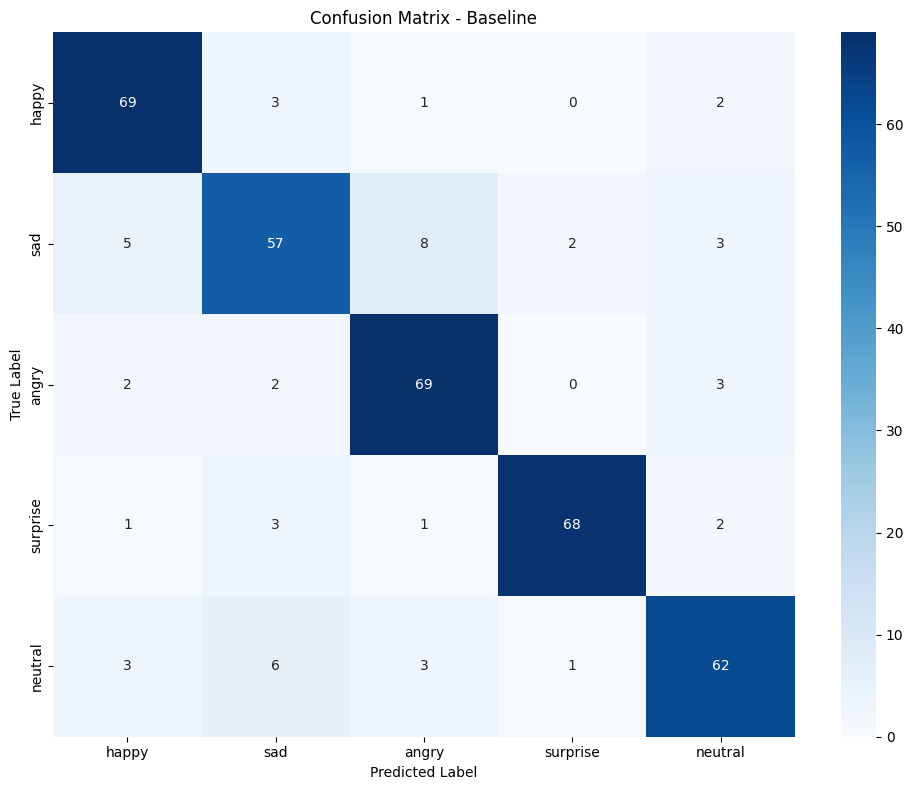

In [4]:

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, classification_report)
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 1. Dataset Class (FIXED)
class EmotionDataset(Dataset):
    # Load image or return black if corrupted
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f" Corrupted image: {img_path}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        # Transform
        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# Verify if image is valid
def verify_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()
        return True
    except:
        return False

# Load valid images with labels
def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    corrupted_count = 0

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([1] * len(valid_images))  # hijab = 1

    #non_hijabi
    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([0] * len(valid_images))  # hijab = 0

    return all_paths, all_emotions, all_hijab


# Stratified split on emotion × hijab
def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):


    print("\n" + "="*70)
    print("Stratified Split")
    print("="*70)

    # create combined labels (emotion × hijab)
    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    # Train + Temp
    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    # Val + Test
    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    print(f"   Train:      {len(X_train):4d} ({len(X_train)/len(paths)*100:.1f}%)")
    print(f"   Validation: {len(X_val):4d} ({len(X_val)/len(paths)*100:.1f}%)")
    print(f"   Test:       {len(X_test):4d} ({len(X_test)/len(paths)*100:.1f}%)")


    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


#  Data Transforms

# train (with augmentation )
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Val/Test (without augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def build_vgg16_baseline(num_classes=5, pretrained=True):
    model = models.vgg16(pretrained=pretrained)
    num_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(num_features, num_classes)
    return model

# One epoch training
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, emotions)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# Evaluate model
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            loss = criterion(outputs, emotions)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    epoch_loss = running_loss / len(dataloader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    return epoch_loss, all_preds, all_labels, all_hijab

# Essential fairness metric
def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):

    results = {}

    # Overall
    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    # Per hijab status
    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    # Fairness gap
    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    # Per emotion
    results['per_emotion'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        mask = (labels == emotion_idx)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            results['per_emotion'][emotion_name] = acc

    # Per emotion × hijab
    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    # Worst-group accuracy
    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):


    print("\n" + "="*70)
    print(" Fairness Report")
    print("="*70)

    # Overall
    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    # Per hijab
    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    # Gap
    gap = results.get('fairness_gap', 0)
    print(f"\n Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    # Per emotion × hijab
    print(f"\nPer Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# Main pipeline
def main():


    print("="*70)
    print("Baseline Model Training - VGG-16")
    print("="*70)

    # 1. load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    # 2. Stratified split
    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # 3. Datasets
    train_dataset = EmotionDataset(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDataset(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDataset(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    # 4. DataLoaders ( num_workers=0 )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )


    # 5. Model
    model = build_vgg16_baseline(num_classes=len(EMOTIONS), pretrained=True)
    model = model.to(DEVICE)

    print(f" ResNet-18 (Pretrained on ImageNet)")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # 6. Loss & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # 7. Training loop


    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )

        # Validate
        val_loss, val_preds, val_labels, val_hijab = evaluate(
            model, val_loader, criterion, DEVICE
        )
        val_acc = accuracy_score(val_labels, val_preds) * 100

        # Scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f" Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_baseline_model.pth')


    print("\n" + "="*70)
    print(f"best Val Accuracy: {best_val_acc:.2f}%")
    print("="*70)

    # 8. Test Evaluation

    # load best model
    model.load_state_dict(torch.load('best_baseline_model.pth'))

    test_loss, test_preds, test_labels, test_hijab = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Fairness metrics
    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix - Baseline')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('baseline_confusion_matrix.png', dpi=150)
    print(f"\n Confusion matrix saved: baseline_confusion_matrix.png")
    #save results
    results_summary = {
        'model': 'ResNet-18 Baseline',
        'best_val_acc': best_val_acc,
        **fairness_results
    }

    import json
    with open('baseline_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)


    return model, fairness_results


if __name__=="__main__":
    main()


Baseline Model (MobileNetV2)

Baseline Model Training - ResNet-18

Stratified Split
   Train:      1751 (70.0%)
   Validation:  375 (15.0%)
   Test:        376 (15.0%)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 200MB/s]


 ResNet-18 (Pretrained on ImageNet)
   Parameters: 2,230,277

Epoch 1/30
----------------------------------------------------------------------


Train Loss: 0.5360 | Train Acc: 80.47%
Val Loss:   0.4791 | Val Acc:   86.67%

Epoch 2/30
----------------------------------------------------------------------


Train Loss: 0.2623 | Train Acc: 91.15%
Val Loss:   0.3222 | Val Acc:   89.60%

Epoch 3/30
----------------------------------------------------------------------


...

Train Loss: 0.0046 | Train Acc: 99.94%
Val Loss:   0.1324 | Val Acc:   97.07%

Epoch 28/30
----------------------------------------------------------------------


Train Loss: 0.0021 | Train Acc: 99.94%
Val Loss:   0.1107 | Val Acc:   97.33%

Epoch 29/30
----------------------------------------------------------------------


 Learning rate reduced: 0.000125 → 0.000063
Train Loss: 0.0013 | Train Acc: 99.94%
Val Loss:   0.1204 | Val Acc:   96.53%

Epoch 30/30
----------------------------------------------------------------------


Train Loss: 0.0035 | Train Acc: 99.94%
Val Loss:   0.1200 | Val Acc:   97.07%

best Val Accuracy: 97.60%



 Fairness Report

 Overall Accuracy: 94.68%

 Per Hijab Status:
   Hijabi:     94.71%
   Non-Hijabi: 94.65%

 Fairness Gap: 0.06%
 Worst-Group Acc: 81.58%

Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        97.30%       100.00%      2.70%     
sad          94.74%       97.30%       2.56%     
angry        86.84%       81.58%       5.26%     
surprise     97.37%       97.30%       0.07%     
neutral      97.37%       97.30%       0.07%     

 Confusion matrix saved: baseline_confusion_matrix.png


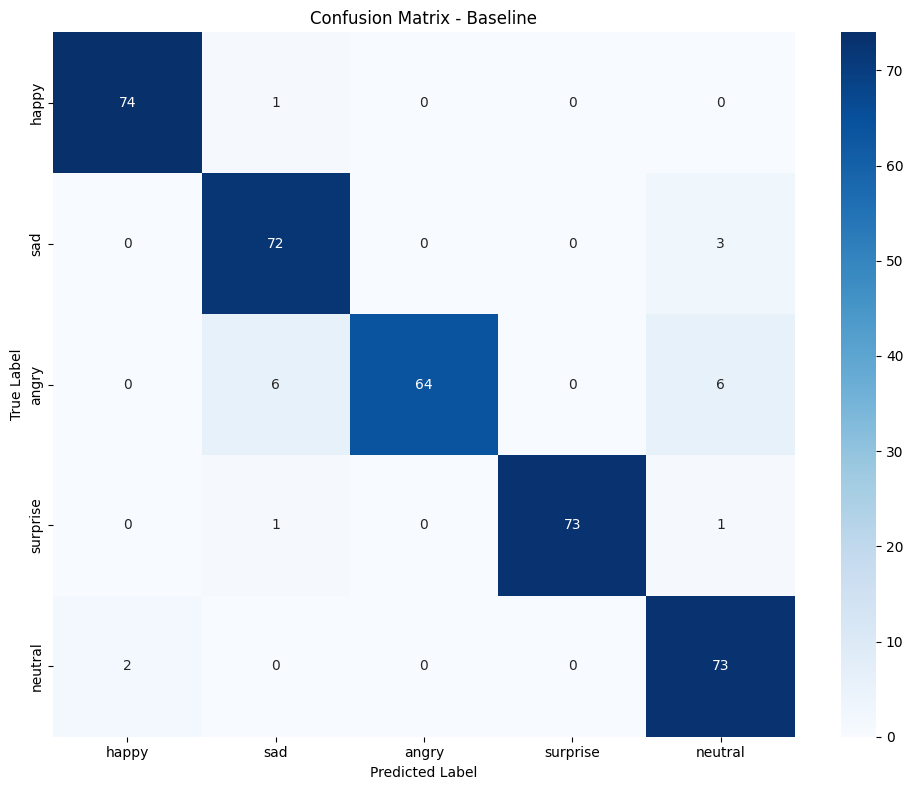

In [5]:

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, classification_report)
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 1. Dataset Class (FIXED)
class EmotionDataset(Dataset):
    # Load image or return black if corrupted
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f" Corrupted image: {img_path}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        # Transform
        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# Verify if image is valid
def verify_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()
        return True
    except:
        return False

# Load valid images with labels
def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    corrupted_count = 0

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([1] * len(valid_images))  # hijab = 1

    #non_hijabi
    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([0] * len(valid_images))  # hijab = 0

    return all_paths, all_emotions, all_hijab


# Stratified split on emotion × hijab
def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):


    print("\n" + "="*70)
    print("Stratified Split")
    print("="*70)

    # create combined labels (emotion × hijab)
    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    # Train + Temp
    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    # Val + Test
    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    print(f"   Train:      {len(X_train):4d} ({len(X_train)/len(paths)*100:.1f}%)")
    print(f"   Validation: {len(X_val):4d} ({len(X_val)/len(paths)*100:.1f}%)")
    print(f"   Test:       {len(X_test):4d} ({len(X_test)/len(paths)*100:.1f}%)")


    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


#  Data Transforms

# train (with augmentation )
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Val/Test (without augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def build_mobilenetv2_baseline(num_classes=5, pretrained=True):
    model = models.mobilenet_v2(pretrained=pretrained)
    num_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(num_features, num_classes)
    return model

# One epoch training
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, emotions)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# Evaluate model
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            loss = criterion(outputs, emotions)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    epoch_loss = running_loss / len(dataloader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    return epoch_loss, all_preds, all_labels, all_hijab

# Essential fairness metric
def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):

    results = {}

    # Overall
    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    # Per hijab status
    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    # Fairness gap
    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    # Per emotion
    results['per_emotion'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        mask = (labels == emotion_idx)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            results['per_emotion'][emotion_name] = acc

    # Per emotion × hijab
    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    # Worst-group accuracy
    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):


    print("\n" + "="*70)
    print(" Fairness Report")
    print("="*70)

    # Overall
    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    # Per hijab
    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    # Gap
    gap = results.get('fairness_gap', 0)
    print(f"\n Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    # Per emotion × hijab
    print(f"\nPer Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# Main pipeline
def main():


    print("="*70)
    print("Baseline Model Training - ResNet-18")
    print("="*70)

    # 1. load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    # 2. Stratified split
    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # 3. Datasets
    train_dataset = EmotionDataset(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDataset(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDataset(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    # 4. DataLoaders ( num_workers=0 )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )


    # 5. Model
    model = build_mobilenetv2_baseline(num_classes=len(EMOTIONS), pretrained=True)
    model = model.to(DEVICE)

    print(f" ResNet-18 (Pretrained on ImageNet)")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # 6. Loss & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # 7. Training loop


    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )

        # Validate
        val_loss, val_preds, val_labels, val_hijab = evaluate(
            model, val_loader, criterion, DEVICE
        )
        val_acc = accuracy_score(val_labels, val_preds) * 100

        # Scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f" Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_baseline_model.pth')


    print("\n" + "="*70)
    print(f"best Val Accuracy: {best_val_acc:.2f}%")
    print("="*70)

    # 8. Test Evaluation

    # load best model
    model.load_state_dict(torch.load('best_baseline_model.pth'))

    test_loss, test_preds, test_labels, test_hijab = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Fairness metrics
    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix - Baseline')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('baseline_confusion_matrix.png', dpi=150)
    print(f"\n Confusion matrix saved: baseline_confusion_matrix.png")
    #save results
    results_summary = {
        'model': 'ResNet-18 Baseline',
        'best_val_acc': best_val_acc,
        **fairness_results
    }

    import json
    with open('baseline_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)


    return model, fairness_results


if __name__=="__main__":
    main()


Baseline (DenseNet121)


Baseline Model Training - ResNet-18

Stratified Split
   Train:      1751 (70.0%)
   Validation:  375 (15.0%)
   Test:        376 (15.0%)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 204MB/s]


 ResNet-18 (Pretrained on ImageNet)
   Parameters: 6,958,981

Epoch 1/30
----------------------------------------------------------------------


Train Loss: 0.5369 | Train Acc: 80.53%
Val Loss:   0.3501 | Val Acc:   88.00%

Epoch 2/30
----------------------------------------------------------------------


Train Loss: 0.3190 | Train Acc: 89.38%
Val Loss:   0.3576 | Val Acc:   89.07%

Epoch 3/30
----------------------------------------------------------------------


...

Train Loss: 0.0013 | Train Acc: 100.00%
Val Loss:   0.1099 | Val Acc:   97.07%

Epoch 28/30
----------------------------------------------------------------------


 Learning rate reduced: 0.000063 → 0.000031
Train Loss: 0.0010 | Train Acc: 100.00%
Val Loss:   0.1118 | Val Acc:   97.07%

Epoch 29/30
----------------------------------------------------------------------


Train Loss: 0.0008 | Train Acc: 100.00%
Val Loss:   0.1058 | Val Acc:   97.60%

Epoch 30/30
----------------------------------------------------------------------


Train Loss: 0.0008 | Train Acc: 100.00%
Val Loss:   0.1109 | Val Acc:   96.80%

best Val Accuracy: 97.60%



 Fairness Report

 Overall Accuracy: 97.07%

 Per Hijab Status:
   Hijabi:     96.83%
   Non-Hijabi: 97.33%

 Fairness Gap: 0.50%
 Worst-Group Acc: 92.11%

Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        100.00%      97.37%       2.63%     
sad          97.37%       97.30%       0.07%     
angry        92.11%       97.37%       5.26%     
surprise     97.37%       94.59%       2.77%     
neutral      97.37%       100.00%      2.63%     

 Confusion matrix saved: baseline_confusion_matrix.png


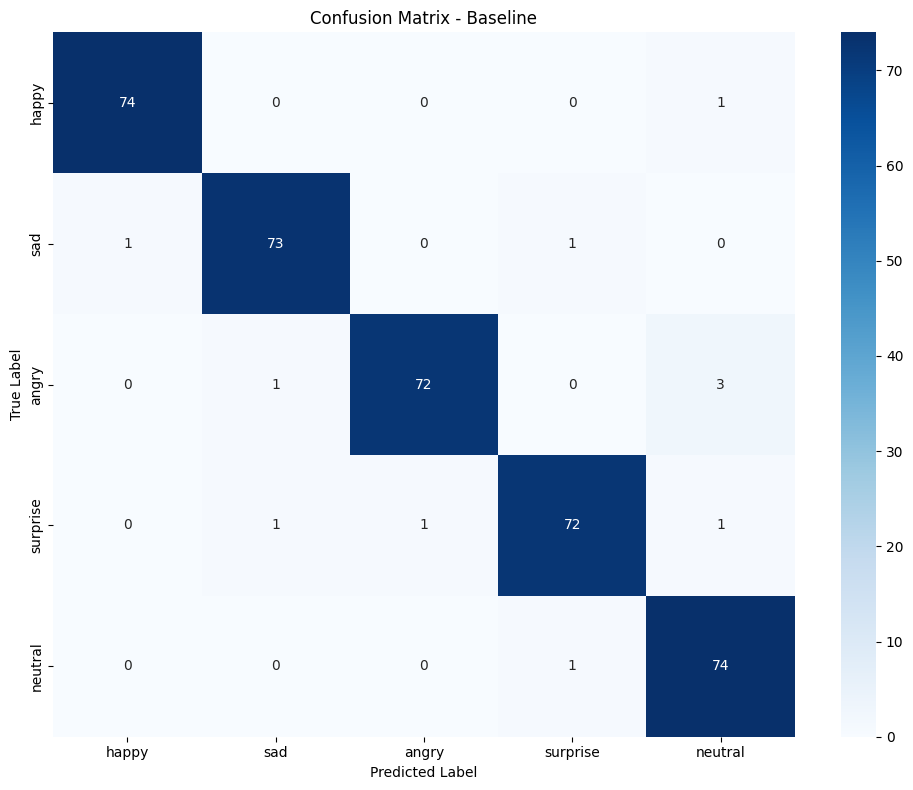

In [6]:

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, classification_report)
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 1. Dataset Class (FIXED)
class EmotionDataset(Dataset):
    # Load image or return black if corrupted
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f" Corrupted image: {img_path}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        # Transform
        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# Verify if image is valid
def verify_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()
        return True
    except:
        return False

# Load valid images with labels
def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    corrupted_count = 0

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([1] * len(valid_images))  # hijab = 1

    #non_hijabi
    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([0] * len(valid_images))  # hijab = 0

    return all_paths, all_emotions, all_hijab


# Stratified split on emotion × hijab
def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):


    print("\n" + "="*70)
    print("Stratified Split")
    print("="*70)

    # create combined labels (emotion × hijab)
    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    # Train + Temp
    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    # Val + Test
    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    print(f"   Train:      {len(X_train):4d} ({len(X_train)/len(paths)*100:.1f}%)")
    print(f"   Validation: {len(X_val):4d} ({len(X_val)/len(paths)*100:.1f}%)")
    print(f"   Test:       {len(X_test):4d} ({len(X_test)/len(paths)*100:.1f}%)")


    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


#  Data Transforms

# train (with augmentation )
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Val/Test (without augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def build_densenet121_baseline(num_classes=5, pretrained=True):
    model = models.densenet121(pretrained=pretrained)
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)
    return model

# One epoch training
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, emotions)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# Evaluate model
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            loss = criterion(outputs, emotions)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    epoch_loss = running_loss / len(dataloader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    return epoch_loss, all_preds, all_labels, all_hijab

# Essential fairness metric
def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):

    results = {}

    # Overall
    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    # Per hijab status
    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    # Fairness gap
    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    # Per emotion
    results['per_emotion'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        mask = (labels == emotion_idx)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            results['per_emotion'][emotion_name] = acc

    # Per emotion × hijab
    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    # Worst-group accuracy
    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):


    print("\n" + "="*70)
    print(" Fairness Report")
    print("="*70)

    # Overall
    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    # Per hijab
    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    # Gap
    gap = results.get('fairness_gap', 0)
    print(f"\n Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    # Per emotion × hijab
    print(f"\nPer Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# Main pipeline
def main():


    print("="*70)
    print("Baseline Model Training - ResNet-18")
    print("="*70)

    # 1. load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    # 2. Stratified split
    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # 3. Datasets
    train_dataset = EmotionDataset(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDataset(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDataset(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    # 4. DataLoaders ( num_workers=0 )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )


    # 5. Model
    model = build_densenet121_baseline(num_classes=len(EMOTIONS), pretrained=True)
    model = model.to(DEVICE)

    print(f" ResNet-18 (Pretrained on ImageNet)")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # 6. Loss & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # 7. Training loop


    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )

        # Validate
        val_loss, val_preds, val_labels, val_hijab = evaluate(
            model, val_loader, criterion, DEVICE
        )
        val_acc = accuracy_score(val_labels, val_preds) * 100

        # Scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f" Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_baseline_model.pth')


    print("\n" + "="*70)
    print(f"best Val Accuracy: {best_val_acc:.2f}%")
    print("="*70)

    # 8. Test Evaluation

    # load best model
    model.load_state_dict(torch.load('best_baseline_model.pth'))

    test_loss, test_preds, test_labels, test_hijab = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Fairness metrics
    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix - Baseline')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('baseline_confusion_matrix.png', dpi=150)
    print(f"\n Confusion matrix saved: baseline_confusion_matrix.png")
    #save results
    results_summary = {
        'model': 'ResNet-18 Baseline',
        'best_val_acc': best_val_acc,
        **fairness_results
    }

    import json
    with open('baseline_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)


    return model, fairness_results


if __name__=="__main__":
    main()


##**Baseline Model**

Baseline Model Training - ResNet-18

Stratified Split
   Train:      1751 (70.0%)
   Validation:  375 (15.0%)
   Test:        376 (15.0%)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


 ResNet-18 (Pretrained on ImageNet)
   Parameters: 11,179,077

Epoch 1/30
----------------------------------------------------------------------


Train Loss: 0.5539 | Train Acc: 80.53%
Val Loss:   0.8202 | Val Acc:   76.00%

Epoch 2/30
----------------------------------------------------------------------


Train Loss: 0.2705 | Train Acc: 91.78%
Val Loss:   0.4580 | Val Acc:   84.53%

Epoch 3/30
----------------------------------------------------------------------


...

Train Loss: 0.0005 | Train Acc: 100.00%
Val Loss:   0.1803 | Val Acc:   96.00%

Epoch 28/30
----------------------------------------------------------------------


 Learning rate reduced: 0.000250 → 0.000125
Train Loss: 0.0004 | Train Acc: 100.00%
Val Loss:   0.1842 | Val Acc:   95.73%

Epoch 29/30
----------------------------------------------------------------------


Train Loss: 0.0010 | Train Acc: 100.00%
Val Loss:   0.1782 | Val Acc:   96.53%

Epoch 30/30
----------------------------------------------------------------------


Train Loss: 0.0008 | Train Acc: 100.00%
Val Loss:   0.1660 | Val Acc:   96.80%

best Val Accuracy: 96.80%



 Fairness Report

 Overall Accuracy: 94.68%

 Per Hijab Status:
   Hijabi:     93.65%
   Non-Hijabi: 95.72%

 Fairness Gap: 2.07%
 Worst-Group Acc: 84.21%

Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        97.30%       97.37%       0.07%     
sad          92.11%       94.59%       2.49%     
angry        84.21%       92.11%       7.89%     
surprise     97.37%       97.30%       0.07%     
neutral      97.37%       97.30%       0.07%     

 Confusion matrix saved: baseline_confusion_matrix.png


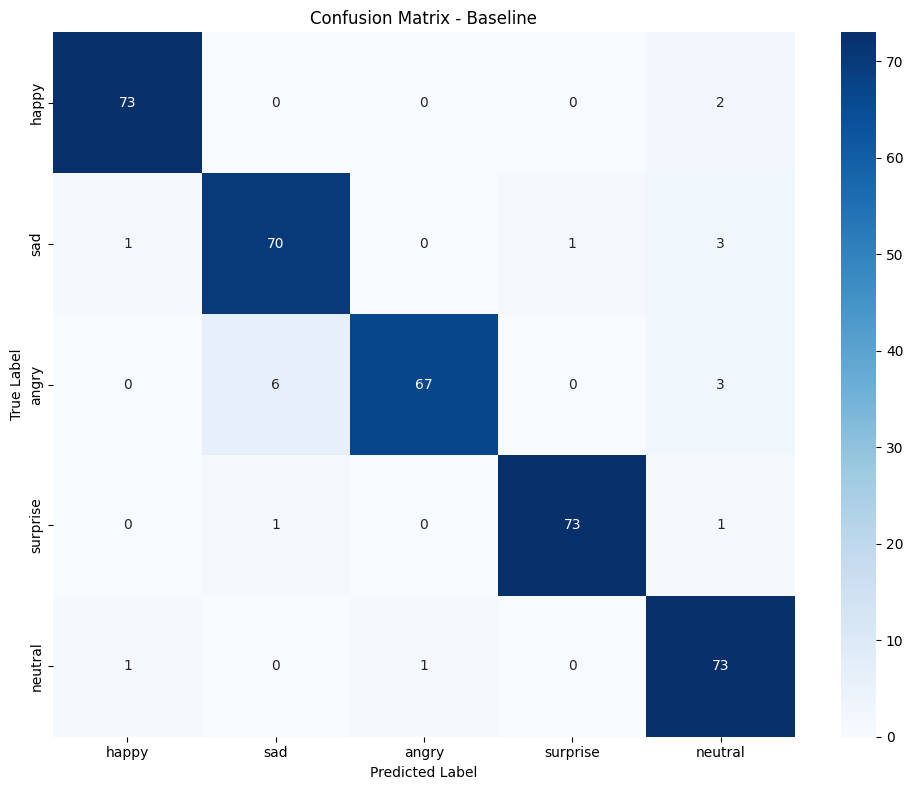

In [11]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, classification_report)
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 1. Dataset Class (FIXED)
class EmotionDataset(Dataset):
    # Load image or return black if corrupted
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f" Corrupted image: {img_path}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        # Transform
        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# Verify if image is valid
def verify_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()
        return True
    except:
        return False

# Load valid images with labels
def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    corrupted_count = 0

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([1] * len(valid_images))  # hijab = 1

    #non_hijabi
    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        valid_images = []
        for img in images:
            if verify_image(img):
                valid_images.append(img)
            else:
                corrupted_count += 1

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(valid_images)
        all_emotions.extend([emotion_idx] * len(valid_images))
        all_hijab.extend([0] * len(valid_images))  # hijab = 0

    return all_paths, all_emotions, all_hijab


# Stratified split on emotion × hijab
def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):


    print("\n" + "="*70)
    print("Stratified Split")
    print("="*70)

    # create combined labels (emotion × hijab)
    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    # Train + Temp
    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    # Val + Test
    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    print(f"   Train:      {len(X_train):4d} ({len(X_train)/len(paths)*100:.1f}%)")
    print(f"   Validation: {len(X_val):4d} ({len(X_val)/len(paths)*100:.1f}%)")
    print(f"   Test:       {len(X_test):4d} ({len(X_test)/len(paths)*100:.1f}%)")


    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


#  Data Transforms

# train (with augmentation )
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Val/Test (without augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# Build baseline model
def build_resnet18_baseline(num_classes=5, pretrained=True):

    #ResNet-18 baseline - emotion classification only

    model = models.resnet18(pretrained=pretrained)

    # change FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    return model


# One epoch training
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, emotions)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# Evaluate model
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            loss = criterion(outputs, emotions)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    epoch_loss = running_loss / len(dataloader)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    return epoch_loss, all_preds, all_labels, all_hijab

# Essential fairness metric
def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):

    results = {}

    # Overall
    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    # Per hijab status
    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    # Fairness gap
    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    # Per emotion
    results['per_emotion'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        mask = (labels == emotion_idx)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            results['per_emotion'][emotion_name] = acc

    # Per emotion × hijab
    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    # Worst-group accuracy
    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):


    print("\n" + "="*70)
    print(" Fairness Report")
    print("="*70)

    # Overall
    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    # Per hijab
    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    # Gap
    gap = results.get('fairness_gap', 0)
    print(f"\n Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    # Per emotion × hijab
    print(f"\nPer Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# Main pipeline
def main():


    print("="*70)
    print("Baseline Model Training - ResNet-18")
    print("="*70)

    # 1. load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    # 2. Stratified split
    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # 3. Datasets
    train_dataset = EmotionDataset(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDataset(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDataset(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    # 4. DataLoaders ( num_workers=0 )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )


    # 5. Model
    model = build_resnet18_baseline(num_classes=len(EMOTIONS), pretrained=True)
    model = model.to(DEVICE)

    print(f" ResNet-18 (Pretrained on ImageNet)")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # 6. Loss & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # 7. Training loop


    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )

        # Validate
        val_loss, val_preds, val_labels, val_hijab = evaluate(
            model, val_loader, criterion, DEVICE
        )
        val_acc = accuracy_score(val_labels, val_preds) * 100

        # Scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f" Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_baseline_model.pth')


    print("\n" + "="*70)
    print(f"best Val Accuracy: {best_val_acc:.2f}%")
    print("="*70)

    # 8. Test Evaluation

    # load best model
    model.load_state_dict(torch.load('best_baseline_model.pth'))

    test_loss, test_preds, test_labels, test_hijab = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Fairness metrics
    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix - Baseline')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('baseline_confusion_matrix.png', dpi=150)
    print(f"\n Confusion matrix saved: baseline_confusion_matrix.png")
    #save results
    results_summary = {
        'model': 'ResNet-18 Baseline',
        'best_val_acc': best_val_acc,
        **fairness_results
    }

    import json
    with open('baseline_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)


    return model, fairness_results


if __name__=="__main__":
    main()

In [ ]:
!ls

baseline_confusion_matrix.png  best_baseline_model.pth	drive
baseline_results.json	       data			sample_data


In [ ]:
from google.colab import files
files.download('best_baseline_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**Balanced Sampling**

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

# Emotion labels and mapping
EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

# Dataset image paths
HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

# Image and training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4

# Select compute device (GPU if available)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 1. Focal loss to focus on hard examples
class FocalLoss(nn.Module):
    # Alpha balances importance, gamma increases focus on misclassified samples
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# 2. Mixup augmentation
def mixup_data(x, y, alpha=0.4):
    # Lambda controls mix ratio between image A and B
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# 3. Dataset with hijab-specific augmentation

class EmotionDatasetAdvanced(Dataset):


    def __init__(self, image_paths, emotions, hijab_labels,
                 transform_hijabi=None, transform_non_hijabi=None, is_train=True):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform_hijabi = transform_hijabi
        self.transform_non_hijabi = transform_non_hijabi
        self.is_train = is_train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        if self.is_train:
            if hijab == 1:
                if self.transform_hijabi:
                    img = self.transform_hijabi(img)
            else:
                if self.transform_non_hijabi:
                    img = self.transform_non_hijabi(img)
        else:
            # Val/Test
            if self.transform_hijabi:
                img = self.transform_hijabi(img)

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }

# 4. Transforms

transform_hijabi_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_non_hijabi_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Val/Test
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# 5.load data

def load_all_data(hijabi_path, non_hijabi_path, emotions):


    all_paths = []
    all_emotions = []
    all_hijab = []

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([1] * len(images))


    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([0] * len(images))



    return all_paths, all_emotions, all_hijab


def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):
    print("\n" + "="*70)
    print("  Stratified Split")
    print("="*70)

    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    print(f"   Train:      {len(X_train):4d}")
    print(f"   Validation: {len(X_val):4d}")
    print(f"   Test:       {len(X_test):4d}")

    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


# 6. Model with Label Smoothing

def build_model_with_label_smoothing(num_classes=5, pretrained=True, dropout=0.6):
    model = models.resnet18(pretrained=pretrained)

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, num_classes)
    )

    return model



# 7. Training with Mixup and Group Monitoring

def train_one_epoch_mixup(model, dataloader, criterion, optimizer, device, use_mixup=True):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)

        if use_mixup and random.random() > 0.5:
            # Mixup
            mixed_images, y_a, y_b, lam = mixup_data(images, emotions, alpha=0.4)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            # Normal
            outputs = model(images)
            loss = criterion(outputs, emotions)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def evaluate_with_groups(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    # compute the accuracy per group
    overall_acc = accuracy_score(all_labels, all_preds)

    hijabi_mask = (all_hijab == 1)
    non_hijabi_mask = (all_hijab == 0)

    hijabi_acc = accuracy_score(all_labels[hijabi_mask], all_preds[hijabi_mask])
    non_hijabi_acc = accuracy_score(all_labels[non_hijabi_mask], all_preds[non_hijabi_mask])

    gap = abs(hijabi_acc - non_hijabi_acc)

    return overall_acc * 100, hijabi_acc * 100, non_hijabi_acc * 100, gap * 100, all_preds, all_labels, all_hijab


# 8. Fairness Metrics

def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):
    results = {}

    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):
    print("\n" + "="*70)
    print("Fairness Report")
    print("="*70)

    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    gap = results.get('fairness_gap', 0)
    print(f"\n Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    print(f"\n Per Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# 9. Main Pipeline

def main():

    # 1. load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    # 2. Split
    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # 3. Datasets with different augmentation

    train_dataset = EmotionDatasetAdvanced(
        train_data[0], train_data[1], train_data[2],
        transform_hijabi=transform_hijabi_train,
        transform_non_hijabi=transform_non_hijabi_train,
        is_train=True
    )

    val_dataset = EmotionDatasetAdvanced(
        val_data[0], val_data[1], val_data[2],
        transform_hijabi=eval_transform,
        transform_non_hijabi=eval_transform,
        is_train=False
    )

    test_dataset = EmotionDatasetAdvanced(
        test_data[0], test_data[1], test_data[2],
        transform_hijabi=eval_transform,
        transform_non_hijabi=eval_transform,
        is_train=False
    )

    # 4. DataLoaders (shuffle without  sampler)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )

    # 5. Model
    model = build_model_with_label_smoothing(
        num_classes=len(EMOTIONS), pretrained=True, dropout=0.6
    )
    model = model.to(DEVICE)

    print(f" ResNet-18 + Dropout(0.6)")

    # 6. Focal Loss + Label Smoothing

    criterion = FocalLoss(alpha=1, gamma=2)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4  # ← monitor gap!
    )

    # 7. Training
    print(f"\n start ({NUM_EPOCHS} epochs)...")
    print("="*70)

    best_gap = 100.0
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Train
        train_loss, train_acc = train_one_epoch_mixup(
            model, train_loader, criterion, optimizer, DEVICE, use_mixup=True
        )

        # Validate with group monitoring
        val_acc, h_acc, nh_acc, gap, _, _, _ = evaluate_with_groups(
            model, val_loader, DEVICE
        )

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(gap)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f"LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Acc: {val_acc:.2f}% | H: {h_acc:.2f}% | NH: {nh_acc:.2f}% | Gap: {gap:.2f}%")

        # Save best based on gap!
        if gap < best_gap:
            best_gap = gap
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_comprehensive_model.pth')

    print("\n" + "="*70)
    print(f" best Fairness Gap: {best_gap:.2f}%")
    print("="*70)

    # 8. Test Evaluation

    model.load_state_dict(torch.load('best_comprehensive_model.pth'))

    _, _, _, _, test_preds, test_labels, test_hijab = evaluate_with_groups(
        model, test_loader, DEVICE
    )

    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    results_summary = {
        'model': 'Comprehensive Solution',
        'best_gap': best_gap,
        **fairness_results
    }

    with open('comprehensive_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)




    try:
        with open('baseline_results.json', 'r') as f:
            baseline = json.load(f)
        with open('step2_results.json', 'r') as f:
            step2 = json.load(f)

        print(f"\n{'Metric':<25} {'Baseline':<12} {'Step2':<12} {'Solution':<12}")
        print("-"*65)

        metrics = [
            ('overall_accuracy', 'Overall'),
            ('hijabi_accuracy', 'Hijabi'),
            ('non_hijabi_accuracy', 'Non-Hijabi'),
            ('fairness_gap', 'Gap'),
            ('worst_group_accuracy', 'Worst-Group')
        ]

        for key, label in metrics:
            b = baseline.get(key, 0)
            s2 = step2.get(key, 0)
            sol = fairness_results.get(key, 0)

            print(f"{label:<25} {b:<12.2%} {s2:<12.2%} {sol:<12.2%}")

    except:
        pass


    return model, fairness_results


if __name__ == "__main__":
    model, results = main()


  Stratified Split
   Train:      3498
   Validation:  750
   Test:        750
 ResNet-18 + Dropout(0.6)

 start (40 epochs)...

Epoch 1/40
----------------------------------------------------------------------


Train Loss: 0.8106 | Train Acc: 45.71%
Val Acc: 68.40% | H: 90.13% | NH: 46.67% | Gap: 43.47%

Epoch 2/40
----------------------------------------------------------------------


Train Loss: 0.6432 | Train Acc: 55.00%
Val Acc: 75.60% | H: 93.60% | NH: 57.60% | Gap: 36.00%

Epoch 3/40
----------------------------------------------------------------------


Train Loss: 0.5106 | Train Acc: 57.60%
Val Acc: 78.40% | H: 91.73% | NH: 65.07% | Gap: 26.67%

Epoch 4/40
----------------------------------------------------------------------


Train Loss: 0.4758 | Train Acc: 62.21%
Val Acc: 76.53% | H: 93.07% | NH: 60.00% | Gap: 33.07%

Epoch 5/40
----------------------------------------------------------------------


...

Train Loss: 0.1626 | Train Acc: 75.70%
Val Acc: 90.27% | H: 98.93% | NH: 81.60% | Gap: 17.33%

Epoch 38/40
----------------------------------------------------------------------


Train Loss: 0.1880 | Train Acc: 76.76%
Val Acc: 90.00% | H: 98.13% | NH: 81.87% | Gap: 16.27%

Epoch 39/40
----------------------------------------------------------------------


Train Loss: 0.1706 | Train Acc: 80.05%
Val Acc: 90.27% | H: 98.13% | NH: 82.40% | Gap: 15.73%

Epoch 40/40
----------------------------------------------------------------------


Train Loss: 0.1745 | Train Acc: 78.96%
Val Acc: 90.27% | H: 98.40% | NH: 82.13% | Gap: 16.27%

 best Fairness Gap: 15.73%



Fairness Report

 Overall Accuracy: 91.33%

 Per Hijab Status:
   Hijabi:     98.93%
   Non-Hijabi: 83.73%

 Fairness Gap: 15.20%
 Worst-Group Acc: 74.67%

 Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        100.00%      85.33%       14.67%    
sad          96.00%       77.33%       18.67%    
angry        98.67%       88.00%       10.67%    
surprise     100.00%      93.33%       6.67%     
neutral      100.00%      74.67%       25.33%    


## **Group-Weighted Loss + Gradual Fine-tuning**


Group                     Baseline Acc    Weight    
--------------------------------------------------
happy_non_hijabi          84.00%          0.53      
happy_hijabi              98.67%          0.50      
sad_non_hijabi            65.33%          0.62      
sad_hijabi                96.00%          0.50      
angry_non_hijabi          82.67%          0.53      
angry_hijabi              98.67%          0.50      
surprise_non_hijabi       86.67%          0.52      
surprise_hijabi           97.33%          0.50      
neutral_non_hijabi        74.67%          0.56      
neutral_hijabi            98.67%          0.50      
 ResNet-18 + Dropout(0.3)

Epoch 1/15
----------------------------------------------------------------------


Train Loss: 0.7969 | Train Acc: 34.85%
Val Acc: 52.00% | H: 66.13% | NH: 37.87% | Gap: 28.27%
Composite: 27.92

Epoch 2/15
----------------------------------------------------------------------


Train Loss: 0.6727 | Train Acc: 48.57%
Val Acc: 56.13% | H: 68.27% | NH: 44.00% | Gap: 24.27%
Composite: 32.01

Epoch 3/15
----------------------------------------------------------------------


Train Loss: 0.6359 | Train Acc: 51.32%
Val Acc: 60.27% | H: 72.27% | NH: 48.27% | Gap: 24.00%
Composite: 34.99

Epoch 4/15
----------------------------------------------------------------------


Train Loss: 0.6157 | Train Acc: 53.74%
Val Acc: 55.87% | H: 68.80% | NH: 42.93% | Gap: 25.87%
Composite: 31.35

Epoch 5/15
----------------------------------------------------------------------


...

Train Loss: 0.0075 | Train Acc: 99.60%
Val Acc: 88.27% | H: 98.67% | NH: 77.87% | Gap: 20.80%
Composite: 55.55

Epoch 22/25
----------------------------------------------------------------------


Train Loss: 0.0046 | Train Acc: 99.83%
Val Acc: 87.87% | H: 98.40% | NH: 77.33% | Gap: 21.07%
Composite: 55.19

Epoch 23/25
----------------------------------------------------------------------


Train Loss: 0.0046 | Train Acc: 99.83%
Val Acc: 88.40% | H: 98.40% | NH: 78.40% | Gap: 20.00%
Composite: 55.88

Epoch 24/25
----------------------------------------------------------------------


Train Loss: 0.0032 | Train Acc: 99.86%
Val Acc: 89.47% | H: 99.20% | NH: 79.73% | Gap: 19.47%
Composite: 56.79

Epoch 25/25
----------------------------------------------------------------------


Train Loss: 0.0028 | Train Acc: 99.94%
Val Acc: 89.07% | H: 99.20% | NH: 78.93% | Gap: 20.27%
Composite: 56.27

 Best Composite Score: 56.79


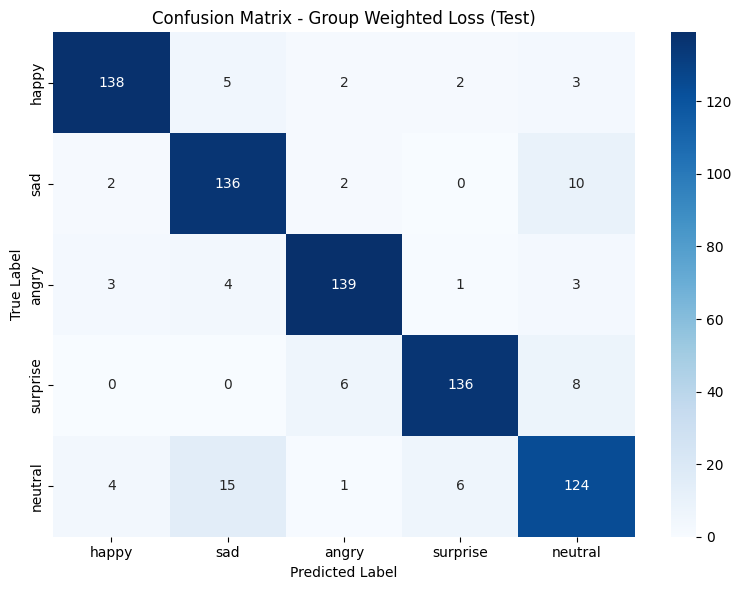


Fairness Report

 Overall Accuracy: 89.73%

 Per Hijab Status:
   Hijabi:     99.20%
   Non-Hijabi: 80.27%

  Fairness Gap: 18.93%
 Worst-Group Acc: 65.33%

 Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        100.00%      84.00%       16.00%    
sad          97.33%       84.00%       13.33%    
angry        98.67%       86.67%       12.00%    
surprise     100.00%      81.33%       18.67%    
neutral      100.00%      65.33%       34.67%    

Metric                    Baseline        Step3           Change         
----------------------------------------------------------------------
Overall Acc               88.27%          89.73%                  +1.47%
Hijabi Acc                97.87%          99.20%                  +1.33%
Non-Hijabi Acc            78.67%          80.27%                  +1.60%
Fairness Gap              19.20%          18.93%                  -0.27%
Worst-Group Acc           65.33

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS_PHASE1 = 15  # Frozen backbone
NUM_EPOCHS_PHASE2 = 25  # Full fine-tuning
LEARNING_RATE_PHASE1 = 1e-3
LEARNING_RATE_PHASE2 = 1e-4


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Group-Weighted Loss

class GroupWeightedLoss(nn.Module):

    def __init__(self, group_weights):
        super().__init__()
        self.group_weights = group_weights  # dict: {group_id: weight}
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, outputs, emotions, hijab_labels):

        # base loss
        losses = self.ce_loss(outputs, emotions)

        weighted_losses = []
        for i in range(len(emotions)):
            emotion = emotions[i].item()
            hijab = hijab_labels[i].item()
            group_id = emotion * 2 + hijab  # 0-9 (5 emotions × 2 hijab)

            weight = self.group_weights.get(group_id, 1.0)
            weighted_losses.append(losses[i] * weight)

        return torch.stack(weighted_losses).mean()


def compute_group_weights(train_emotions, train_hijab, baseline_results):

    per_emotion_hijab = baseline_results.get('per_emotion_hijab', {})

    group_weights = {}

    print(f"\n{'Group':<25} {'Baseline Acc':<15} {'Weight':<10}")
    print("-"*50)

    for emotion_idx, emotion_name in enumerate(EMOTIONS):
        for hijab_status in [0, 1]:
            hijab_label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            key = f"{emotion_name}_{hijab_label}"

            # Baseline accuracy
            baseline_acc = per_emotion_hijab.get(key, 0.85)  # default 85%

            weight = (1.0 - baseline_acc) ** 2 + 0.5

            group_id = emotion_idx * 2 + hijab_status
            group_weights[group_id] = weight

            print(f"{key:<25} {baseline_acc:<15.2%} {weight:<10.2f}")

    print("="*70)

    return group_weights


# 2. Dataset

class EmotionDatasetSimple(Dataset):

    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# 3. Transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# 4. Load Data

def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([1] * len(images))

    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([0] * len(images))

    return all_paths, all_emotions, all_hijab


def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):

    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


# 5. Model with Dropout

def build_model(num_classes=5, pretrained=True, dropout=0.3):

    model = models.resnet18(pretrained=pretrained)

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, num_classes)
    )

    return model


# 6. Training

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)
        hijab = batch['hijab'].to(device)

        outputs = model(images)
        loss = criterion(outputs, emotions, hijab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += emotions.size(0)
        correct += predicted.eq(emotions).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def evaluate_with_groups(model, dataloader, device):

    model.eval()

    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    overall_acc = accuracy_score(all_labels, all_preds)

    hijabi_mask = (all_hijab == 1)
    non_hijabi_mask = (all_hijab == 0)

    hijabi_acc = accuracy_score(all_labels[hijabi_mask], all_preds[hijabi_mask])
    non_hijabi_acc = accuracy_score(all_labels[non_hijabi_mask], all_preds[non_hijabi_mask])

    gap = abs(hijabi_acc - non_hijabi_acc)

    return overall_acc * 100, hijabi_acc * 100, non_hijabi_acc * 100, gap * 100, all_preds, all_labels, all_hijab


# 7. Fairness Metrics

def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):
    results = {}

    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):
    print("\n" + "="*70)
    print("Fairness Report")
    print("="*70)

    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    gap = results.get('fairness_gap', 0)
    print(f"\n  Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    print(f"\n Per Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# 8. Composite Metric

def compute_composite_metric(overall_acc, gap, alpha=0.7):
    return alpha * overall_acc - (1 - alpha) * gap


# 9. Main Pipeline

def main():

    # Load baseline results
    try:
        with open('baseline_results.json', 'r') as f:
            baseline_results = json.load(f)
    except:
        baseline_results = {
            'per_emotion_hijab': {
                'happy_hijabi': 0.97, 'happy_non_hijabi': 0.84,
                'sad_hijabi': 0.95, 'sad_non_hijabi': 0.55,
                'angry_hijabi': 0.86, 'angry_non_hijabi': 0.87,
                'surprise_hijabi': 0.97, 'surprise_non_hijabi': 0.87,
                'neutral_hijabi': 0.97, 'neutral_non_hijabi': 0.68
            }
        }

    # Load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # Compute group weights
    group_weights = compute_group_weights(
        train_data[1], train_data[2], baseline_results
    )

    # Datasets
    train_dataset = EmotionDatasetSimple(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDatasetSimple(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDatasetSimple(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )

    # Model
    model = build_model(num_classes=len(EMOTIONS), pretrained=True, dropout=0.3)
    model = model.to(DEVICE)

    print(f" ResNet-18 + Dropout(0.3)")

    # Loss & Optimizer
    criterion = GroupWeightedLoss(group_weights)

    # PHASE 1: Frozen Backbone
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer_phase1 = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE_PHASE1,
        weight_decay=1e-4
    )

    scheduler_phase1 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_phase1, mode='max', factor=0.5, patience=3
    )

    best_composite = -100.0
    best_model_state = None

    for epoch in range(NUM_EPOCHS_PHASE1):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_PHASE1}")
        print("-"*70)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer_phase1, DEVICE
        )

        val_acc, h_acc, nh_acc, gap, _, _, _ = evaluate_with_groups(
            model, val_loader, DEVICE
        )

        composite = compute_composite_metric(val_acc, gap, alpha=0.7)

        scheduler_phase1.step(composite)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Acc: {val_acc:.2f}% | H: {h_acc:.2f}% | NH: {nh_acc:.2f}% | Gap: {gap:.2f}%")
        print(f"Composite: {composite:.2f}")

        if composite > best_composite:
            best_composite = composite
            best_model_state = model.state_dict().copy()

    # PHASE 2: Full Fine-tuning
    model.load_state_dict(best_model_state)

    for param in model.parameters():
        param.requires_grad = True

    optimizer_phase2 = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE_PHASE2,
        weight_decay=1e-4
    )

    scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_phase2, mode='max', factor=0.5, patience=4
    )

    for epoch in range(NUM_EPOCHS_PHASE2):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_PHASE2}")
        print("-"*70)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer_phase2, DEVICE
        )

        val_acc, h_acc, nh_acc, gap, _, _, _ = evaluate_with_groups(
            model, val_loader, DEVICE
        )

        composite = compute_composite_metric(val_acc, gap, alpha=0.7)

        scheduler_phase2.step(composite)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Acc: {val_acc:.2f}% | H: {h_acc:.2f}% | NH: {nh_acc:.2f}% | Gap: {gap:.2f}%")
        print(f"Composite: {composite:.2f}")

        if composite > best_composite:
            best_composite = composite
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_step3_model.pth')

    print("\n" + "="*70)
    print(f" Best Composite Score: {best_composite:.2f}")
    print("="*70)

    # Test Evaluation
    model.load_state_dict(torch.load('best_step3_model.pth'))

    _, _, _, _, test_preds, test_labels, test_hijab = evaluate_with_groups(
        model, test_loader, DEVICE
    )

    # Confusion Matrix (Test Set)
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTIONS, yticklabels=EMOTIONS, cmap='Blues')
    plt.title('Confusion Matrix - Group Weighted Loss (Test)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Save results
    results_summary = {
        'model': 'Step 3: Smart Solution',
        'best_composite': best_composite,
        **fairness_results
    }

    with open('step3_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)

    # =========================
    # Final Comparison (FIXED)
    # =========================
    if os.path.exists('baseline_results.json'):
        with open('baseline_results.json', 'r') as f:
            baseline = json.load(f)

        print(f"\n{'Metric':<25} {'Baseline':<15} {'Step3':<15} {'Change':<15}")
        print("-"*70)

        metrics = [
            ('overall_accuracy', 'Overall Acc'),
            ('hijabi_accuracy', 'Hijabi Acc'),
            ('non_hijabi_accuracy', 'Non-Hijabi Acc'),
            ('fairness_gap', 'Fairness Gap'),
            ('worst_group_accuracy', 'Worst-Group Acc')
        ]

        for key, label in metrics:
            b = baseline.get(key, 0)
            s3 = fairness_results.get(key, 0)
            change = s3 - b
            print(f"{label:<25} {b:<15.2%} {s3:<15.2%} {change:>+14.2%}")

    else:
        print("⚠️ baseline_results.json غير موجود في هذا الـ runtime، لذلك لا يمكن عمل مقارنة نهائية.")

    return model, fairness_results


if __name__ == "__main__":
    model, results = main()


##**Domain Adversarial Neural Network**

In [ ]:
#Step 4: DANN - Domain Adversarial Neural Network

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 35
LEARNING_RATE = 1e-4

# DANN hyperparameters
LAMBDA_DOMAIN = 0.1
LAMBDA_START_EPOCH = 5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")

# 1. Gradient Reversal Layer ( DANN!)

class GradientReversalFunction(Function):

    @staticmethod
    def forward(ctx, x, lambda_param):
        ctx.lambda_param = lambda_param
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.lambda_param
        return output, None


class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, lambda_param=1.0):
        return GradientReversalFunction.apply(x, lambda_param)


# 2. DANN Model

class DANNModel(nn.Module):

    def __init__(self, num_emotions=5, dropout=0.3):
        super().__init__()

        # Feature Extractor (ResNet-18 without FC)
        resnet = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(resnet.children())[:-1])  # بدون FC

        feature_dim = 512  # ResNet-18 output

        # Emotion Classifier
        self.emotion_classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_emotions)
        )

        # Gradient Reversal Layer
        self.grl = GradientReversalLayer()

        # Domain Classifier (hijabi vs non-hijabi)
        self.domain_classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)  # binary: hijabi/non-hijabi
        )

        # Attention mechanism (optional - للـ interpretability)
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x, lambda_param=0.0):
        # Extract features
        features = self.features(x)
        features = features.view(features.size(0), -1)  # flatten

        # Emotion prediction
        emotion_pred = self.emotion_classifier(features)

        # Domain prediction (مع gradient reversal!)
        reversed_features = self.grl(features, lambda_param)
        domain_pred = self.domain_classifier(reversed_features)

        return emotion_pred, domain_pred, features


# 3. Dataset

class EmotionDatasetDANN(Dataset):
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# 4. Transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# 5. Data Loading

def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([1] * len(images))

    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([0] * len(images))

        print(f"   {emotion:12s}: {len(images)} صورة")

    return all_paths, all_emotions, all_hijab


def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):

    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


# 6. Training with DANN

def compute_lambda_param(epoch, total_epochs, start_epoch=5):

    if epoch < start_epoch:
        return 0.0

    p = (epoch - start_epoch) / (total_epochs - start_epoch)
    lambda_p = 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0
    return lambda_p * LAMBDA_DOMAIN


def train_one_epoch_dann(model, dataloader, optimizer, device, lambda_param):

    model.train()

    emotion_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    running_emotion_loss = 0.0
    running_domain_loss = 0.0
    emotion_correct = 0
    domain_correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)
        hijab = batch['hijab'].to(device)

        optimizer.zero_grad()

        # Forward
        emotion_pred, domain_pred, features = model(images, lambda_param)

        # Losses
        emotion_loss = emotion_criterion(emotion_pred, emotions)
        domain_loss = domain_criterion(domain_pred, hijab)

        # Total loss
        total_loss = emotion_loss + domain_loss

        # Backward
        total_loss.backward()
        optimizer.step()

        # Statistics
        running_emotion_loss += emotion_loss.item()
        running_domain_loss += domain_loss.item()

        _, emotion_predicted = emotion_pred.max(1)
        _, domain_predicted = domain_pred.max(1)

        total += emotions.size(0)
        emotion_correct += emotion_predicted.eq(emotions).sum().item()
        domain_correct += domain_predicted.eq(hijab).sum().item()

    epoch_emotion_loss = running_emotion_loss / len(dataloader)
    epoch_domain_loss = running_domain_loss / len(dataloader)
    epoch_emotion_acc = 100. * emotion_correct / total
    epoch_domain_acc = 100. * domain_correct / total

    return epoch_emotion_loss, epoch_domain_loss, epoch_emotion_acc, epoch_domain_acc


def evaluate_with_groups(model, dataloader, device):

    model.eval()

    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            emotion_pred, _, _ = model(images, lambda_param=0.0)
            _, predicted = emotion_pred.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    # metrics
    overall_acc = accuracy_score(all_labels, all_preds)

    hijabi_mask = (all_hijab == 1)
    non_hijabi_mask = (all_hijab == 0)

    hijabi_acc = accuracy_score(all_labels[hijabi_mask], all_preds[hijabi_mask])
    non_hijabi_acc = accuracy_score(all_labels[non_hijabi_mask], all_preds[non_hijabi_mask])

    gap = abs(hijabi_acc - non_hijabi_acc)

    return overall_acc * 100, hijabi_acc * 100, non_hijabi_acc * 100, gap * 100, all_preds, all_labels, all_hijab


# 7. Fairness Metrics

def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):
    results = {}

    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):
    print("Fairness Report")
    print("="*70)

    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    gap = results.get('fairness_gap', 0)
    print(f"\n  Fairness Gap: {gap:.2%}")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

    print("="*70)


# 8. Main Pipeline

def main():

    # Load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # Datasets
    train_dataset = EmotionDatasetDANN(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDatasetDANN(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDatasetDANN(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )

    # Model
    model = DANNModel(num_emotions=len(EMOTIONS), dropout=0.3)
    model = model.to(DEVICE)

    # Optimizer
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    print(f"   - Epochs: {NUM_EPOCHS}")
    print(f"   - Learning rate: {LEARNING_RATE}")
    print(f"   - Lambda domain: {LAMBDA_DOMAIN}")
    print(f"   - Lambda start: epoch {LAMBDA_START_EPOCH}")

    # Training
    print("="*70)

    best_gap = 100.0
    best_composite = -100.0
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        # Dynamic lambda
        lambda_param = compute_lambda_param(epoch, NUM_EPOCHS, LAMBDA_START_EPOCH)

        # Train
        emotion_loss, domain_loss, emotion_acc, domain_acc = train_one_epoch_dann(
            model, train_loader, optimizer, DEVICE, lambda_param
        )

        # Validate
        val_acc, h_acc, nh_acc, gap, _, _, _ = evaluate_with_groups(
            model, val_loader, DEVICE
        )

        # Composite metric
        composite = 0.7 * val_acc - 0.3 * gap

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(composite)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f"LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        print(f"Train → Emotion: {emotion_acc:.2f}% | Domain: {domain_acc:.2f}% | λ={lambda_param:.3f}")
        print(f"Val   → Acc: {val_acc:.2f}% | H: {h_acc:.2f}% | NH: {nh_acc:.2f}% | Gap: {gap:.2f}%")
        print(f"Composite: {composite:.2f}")

        # Save best
        if composite > best_composite:
            best_composite = composite
            best_gap = gap
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_dann_model.pth')

    print("\n" + "="*70)
    print(f" Best Composite: {best_composite:.2f}")
    print(f" Best Gap: {best_gap:.2f}%")
    print("="*70)

    # Test Evaluation
    model.load_state_dict(torch.load('best_dann_model.pth'))

    _, _, _, _, test_preds, test_labels, test_hijab = evaluate_with_groups(
        model, test_loader, DEVICE
    )

    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Save results
    results_summary = {
        'model': 'DANN',
        'best_composite': best_composite,
        'best_gap': best_gap,
        **fairness_results
    }

    with open('dann_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)

    # Final Comparison (FIXED ONLY HERE)
    print("\n" + "="*70)

    if os.path.exists('baseline_results.json'):
        with open('baseline_results.json', 'r') as f:
            baseline = json.load(f)

        print(f"\n{'Metric':<25} {'Baseline':<15} {'DANN':<15} {'Change':<15}")
        print("-"*70)

        metrics = [
            ('overall_accuracy', 'Overall Acc'),
            ('hijabi_accuracy', 'Hijabi Acc'),
            ('non_hijabi_accuracy', 'Non-Hijabi Acc'),
            ('fairness_gap', 'Fairness Gap'),
            ('worst_group_accuracy', 'Worst-Group Acc')
        ]

        for key, label in metrics:
            b = baseline.get(key, 0)
            d = fairness_results.get(key, 0)
            change = d - b
            print(f"{label:<25} {b:<15.2%} {d:<15.2%} {change:>+14.2%}")

    else:
        print("⚠️ baseline_results.json غير موجود، لذلك لا يمكن عمل مقارنة نهائية.")

    return model, fairness_results


if __name__ == "__main__":
    model, results = main()


🖥️  Device: cuda
   happy       : 500 صورة
   sad         : 500 صورة
   angry       : 500 صورة
   surprise    : 500 صورة
   neutral     : 500 صورة
   - Epochs: 35
   - Learning rate: 0.0001
   - Lambda domain: 0.1
   - Lambda start: epoch 5

Epoch 1/35
----------------------------------------------------------------------


Train → Emotion: 59.92% | Domain: 81.85% | λ=0.000
Val   → Acc: 79.20% | H: 94.13% | NH: 64.27% | Gap: 29.87%
Composite: 46.48

Epoch 2/35
----------------------------------------------------------------------


Train → Emotion: 80.33% | Domain: 93.05% | λ=0.000
Val   → Acc: 82.27% | H: 94.93% | NH: 69.60% | Gap: 25.33%
Composite: 49.99

Epoch 3/35
----------------------------------------------------------------------


Train → Emotion: 87.54% | Domain: 95.51% | λ=0.000
Val   → Acc: 82.53% | H: 94.13% | NH: 70.93% | Gap: 23.20%
Composite: 50.81

Epoch 4/35
----------------------------------------------------------------------


Train → Emotion: 90.28% | Domain: 96.60% | λ=0.000
Val   → Acc: 87.73% | H: 97.33% | NH: 78.13% | Gap: 19.20%
Composite: 55.65

Epoch 5/35
----------------------------------------------------------------------


...

Train → Emotion: 99.89% | Domain: 50.91% | λ=0.100
Val   → Acc: 89.07% | H: 98.67% | NH: 79.47% | Gap: 19.20%
Composite: 56.59

Epoch 33/35
----------------------------------------------------------------------


LR reduced: 0.000013 → 0.000006
Train → Emotion: 99.94% | Domain: 39.05% | λ=0.100
Val   → Acc: 89.20% | H: 98.67% | NH: 79.73% | Gap: 18.93%
Composite: 56.76

Epoch 34/35
----------------------------------------------------------------------


Train → Emotion: 99.94% | Domain: 42.68% | λ=0.100
Val   → Acc: 89.33% | H: 98.67% | NH: 80.00% | Gap: 18.67%
Composite: 56.93

Epoch 35/35
----------------------------------------------------------------------


Train → Emotion: 99.97% | Domain: 49.46% | λ=0.100
Val   → Acc: 89.47% | H: 98.67% | NH: 80.27% | Gap: 18.40%
Composite: 57.11

 Best Composite: 57.11
 Best Gap: 18.40%


Fairness Report

 Overall Accuracy: 90.67%

 Per Hijab Status:
   Hijabi:     99.20%
   Non-Hijabi: 82.13%

  Fairness Gap: 17.07%
 Worst-Group Acc: 74.67%


Metric                    Baseline        DANN            Change         
----------------------------------------------------------------------
Overall Acc               88.80%          90.67%                  +1.87%
Hijabi Acc                97.87%          99.20%                  +1.33%
Non-Hijabi Acc            79.73%          82.13%                  +2.40%
Fairness Gap              18.13%          17.07%                  -1.07%
Worst-Group Acc           68.00%          74.67%                  +6.67%


##**DANN Fixed - Optimized Hyperparameters**

In [ ]:
#Step 4.1: DANN Fixed - Optimized Hyperparameters


import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm


EMOTIONS = ['happy', 'sad', 'angry', 'surprise', 'neutral']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

HIJABI_PATH = '/content/data/raw/hijabi'
NON_HIJABI_PATH = '/content/data/raw/non_hijabi'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40

# Learning rates (differential!)
LR_BACKBONE = 1e-5
LR_HEADS = 1e-4

# DANN hyperparameters
LAMBDA_DOMAIN = 0.03
LAMBDA_START_EPOCH = 10

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")

# 1. Gradient Reversal Layer

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lambda_param):
        ctx.lambda_param = lambda_param
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.lambda_param
        return output, None


class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, lambda_param=1.0):
        return GradientReversalFunction.apply(x, lambda_param)


# 2. DANN Model

class DANNModel(nn.Module):
    def __init__(self, num_emotions=5, dropout=0.3):
        super().__init__()

        resnet = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(resnet.children())[:-1])

        feature_dim = 512

        self.emotion_classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_emotions)
        )

        self.grl = GradientReversalLayer()

        self.domain_classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x, lambda_param=0.0):
        features = self.features(x)
        features = features.view(features.size(0), -1)

        emotion_pred = self.emotion_classifier(features)

        reversed_features = self.grl(features, lambda_param)
        domain_pred = self.domain_classifier(reversed_features)

        return emotion_pred, domain_pred, features


# 3. Dataset

class EmotionDatasetDANN(Dataset):
    def __init__(self, image_paths, emotions, hijab_labels, transform=None):
        self.image_paths = image_paths
        self.emotions = emotions
        self.hijab_labels = hijab_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        emotion = self.emotions[idx]
        hijab = self.hijab_labels[idx]

        return {
            'image': img,
            'emotion': emotion,
            'hijab': hijab,
            'path': img_path
        }


# 4. Transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# 5. Data Loading

def load_all_data(hijabi_path, non_hijabi_path, emotions):

    all_paths = []
    all_emotions = []
    all_hijab = []

    for emotion in emotions:
        folder = os.path.join(hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([1] * len(images))

        print(f"   {emotion:12s}: {len(images)} صورة")

    for emotion in emotions:
        folder = os.path.join(non_hijabi_path, emotion)
        if not os.path.exists(folder):
            continue

        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        emotion_idx = EMOTION_TO_IDX[emotion]

        all_paths.extend(images)
        all_emotions.extend([emotion_idx] * len(images))
        all_hijab.extend([0] * len(images))



    return all_paths, all_emotions, all_hijab


def stratified_split(paths, emotions, hijab_labels, test_size=0.15, val_size=0.15):

    combined = [e * 2 + h for e, h in zip(emotions, hijab_labels)]

    X_train, X_temp, y_train, y_temp, h_train, h_temp = train_test_split(
        paths, emotions, hijab_labels,
        test_size=(test_size + val_size),
        stratify=combined,
        random_state=42
    )

    combined_temp = [e * 2 + h for e, h in zip(y_temp, h_temp)]
    val_ratio = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test, h_val, h_test = train_test_split(
        X_temp, y_temp, h_temp,
        test_size=(1 - val_ratio),
        stratify=combined_temp,
        random_state=42
    )

    return (X_train, y_train, h_train), (X_val, y_val, h_val), (X_test, y_test, h_test)


# 6. Lambda Schedule

def compute_lambda_param(epoch, total_epochs, start_epoch=10):

    if epoch < start_epoch:
        return 0.0

    p = (epoch - start_epoch) / (total_epochs - start_epoch)
    lambda_p = 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0
    return lambda_p * LAMBDA_DOMAIN  # ← max = 0.03


# 7. Training (with differential LR!)


def train_one_epoch_dann(model, dataloader, optimizers, device, lambda_param):

    model.train()

    emotion_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    running_emotion_loss = 0.0
    running_domain_loss = 0.0
    emotion_correct = 0
    domain_correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        emotions = batch['emotion'].to(device)
        hijab = batch['hijab'].to(device)

        # Zero grad both optimizers
        for opt in optimizers:
            opt.zero_grad()

        # Forward
        emotion_pred, domain_pred, features = model(images, lambda_param)

        # Losses
        emotion_loss = emotion_criterion(emotion_pred, emotions)
        domain_loss = domain_criterion(domain_pred, hijab)

        total_loss = emotion_loss + domain_loss

        # Backward
        total_loss.backward()

        # Step both optimizers
        for opt in optimizers:
            opt.step()

        # Statistics
        running_emotion_loss += emotion_loss.item()
        running_domain_loss += domain_loss.item()

        _, emotion_predicted = emotion_pred.max(1)
        _, domain_predicted = domain_pred.max(1)

        total += emotions.size(0)
        emotion_correct += emotion_predicted.eq(emotions).sum().item()
        domain_correct += domain_predicted.eq(hijab).sum().item()

    epoch_emotion_loss = running_emotion_loss / len(dataloader)
    epoch_domain_loss = running_domain_loss / len(dataloader)
    epoch_emotion_acc = 100. * emotion_correct / total
    epoch_domain_acc = 100. * domain_correct / total

    return epoch_emotion_loss, epoch_domain_loss, epoch_emotion_acc, epoch_domain_acc


def evaluate_with_groups(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_hijab = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            emotions = batch['emotion'].to(device)
            hijab = batch['hijab'].numpy()

            emotion_pred, _, _ = model(images, lambda_param=0.0)
            _, predicted = emotion_pred.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(emotions.cpu().numpy())
            all_hijab.extend(hijab)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_hijab = np.array(all_hijab)

    overall_acc = accuracy_score(all_labels, all_preds)

    hijabi_mask = (all_hijab == 1)
    non_hijabi_mask = (all_hijab == 0)

    hijabi_acc = accuracy_score(all_labels[hijabi_mask], all_preds[hijabi_mask])
    non_hijabi_acc = accuracy_score(all_labels[non_hijabi_mask], all_preds[non_hijabi_mask])

    gap = abs(hijabi_acc - non_hijabi_acc)

    #  worst-group
    worst_group_acc = 1.0
    for emotion_idx in range(len(EMOTIONS)):
        for hijab_status in [0, 1]:
            mask = (all_labels == emotion_idx) & (all_hijab == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(all_labels[mask], all_preds[mask])
                worst_group_acc = min(worst_group_acc, acc)

    return (overall_acc * 100, hijabi_acc * 100, non_hijabi_acc * 100,
            gap * 100, worst_group_acc * 100, all_preds, all_labels, all_hijab)


# 8. Fairness Metrics

def compute_fairness_metrics(preds, labels, hijab_labels, emotions_list):
    results = {}

    overall_acc = accuracy_score(labels, preds)
    results['overall_accuracy'] = overall_acc

    for hijab_status in [0, 1]:
        mask = (hijab_labels == hijab_status)
        if mask.sum() > 0:
            acc = accuracy_score(labels[mask], preds[mask])
            label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
            results[f'{label}_accuracy'] = acc

    if 'hijabi_accuracy' in results and 'non_hijabi_accuracy' in results:
        gap = abs(results['hijabi_accuracy'] - results['non_hijabi_accuracy'])
        results['fairness_gap'] = gap

    results['per_emotion_hijab'] = {}
    for emotion_idx, emotion_name in enumerate(emotions_list):
        for hijab_status in [0, 1]:
            mask = (labels == emotion_idx) & (hijab_labels == hijab_status)
            if mask.sum() > 0:
                acc = accuracy_score(labels[mask], preds[mask])
                label = 'hijabi' if hijab_status == 1 else 'non_hijabi'
                key = f"{emotion_name}_{label}"
                results['per_emotion_hijab'][key] = acc

    group_accs = list(results['per_emotion_hijab'].values())
    results['worst_group_accuracy'] = min(group_accs) if group_accs else 0

    return results


def print_fairness_report(results, emotions_list):
    print("Fairness Report")
    print("="*70)

    print(f"\n Overall Accuracy: {results['overall_accuracy']:.2%}")

    print(f"\n Per Hijab Status:")
    print(f"   Hijabi:     {results.get('hijabi_accuracy', 0):.2%}")
    print(f"   Non-Hijabi: {results.get('non_hijabi_accuracy', 0):.2%}")

    gap = results.get('fairness_gap', 0)
    print(f"\nFairness Gap: {gap:.2%} ")
    print(f" Worst-Group Acc: {results['worst_group_accuracy']:.2%}")

    print(f"\n Per Emotion × Hijab:")
    print(f"{'Emotion':<12} {'Hijabi':<12} {'Non-Hijabi':<12} {'Gap':<10}")
    print("-"*50)

    for emotion in emotions_list:
        h_key = f"{emotion}_hijabi"
        nh_key = f"{emotion}_non_hijabi"

        h_acc = results['per_emotion_hijab'].get(h_key, 0)
        nh_acc = results['per_emotion_hijab'].get(nh_key, 0)
        gap = abs(h_acc - nh_acc)

        print(f"{emotion:<12} {h_acc:<12.2%} {nh_acc:<12.2%} {gap:<10.2%}")

    print("="*70)


# ═══════════════════════════════════════════════════════════════
# 9. Main Pipeline
# ═══════════════════════════════════════════════════════════════

def main():

    # Load data
    all_paths, all_emotions, all_hijab = load_all_data(
        HIJABI_PATH, NON_HIJABI_PATH, EMOTIONS
    )

    train_data, val_data, test_data = stratified_split(
        all_paths, all_emotions, all_hijab
    )

    # Datasets


    train_dataset = EmotionDatasetDANN(
        train_data[0], train_data[1], train_data[2], transform=train_transform
    )
    val_dataset = EmotionDatasetDANN(
        val_data[0], val_data[1], val_data[2], transform=eval_transform
    )
    test_dataset = EmotionDatasetDANN(
        test_data[0], test_data[1], test_data[2], transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )

    # Model
    model = DANNModel(num_emotions=len(EMOTIONS), dropout=0.3)
    model = model.to(DEVICE)

    print(f" DANN Architecture (Fixed)")

    # Optimizers (differential LR!)
    print(f"\n  Differential Learning Rates:")
    print(f"   - Backbone: {LR_BACKBONE}")
    print(f"   - Heads:    {LR_HEADS}")

    optimizer_backbone = optim.AdamW(
        model.features.parameters(),
        lr=LR_BACKBONE,
        weight_decay=1e-4
    )

    optimizer_heads = optim.AdamW(
        list(model.emotion_classifier.parameters()) +
        list(model.domain_classifier.parameters()),
        lr=LR_HEADS,
        weight_decay=1e-4
    )

    optimizers = [optimizer_backbone, optimizer_heads]

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_heads, mode='max', factor=0.5, patience=5
    )

    # Training

    best_worst_group = 0.0
    best_gap = 100.0
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*70)

        lambda_param = compute_lambda_param(epoch, NUM_EPOCHS, LAMBDA_START_EPOCH)

        # Train
        emotion_loss, domain_loss, emotion_acc, domain_acc = train_one_epoch_dann(
            model, train_loader, optimizers, DEVICE, lambda_param
        )

        # Validate
        val_acc, h_acc, nh_acc, gap, worst_group, _, _, _ = evaluate_with_groups(
            model, val_loader, DEVICE
        )

        old_lr = optimizer_heads.param_groups[0]['lr']
        scheduler.step(worst_group)
        new_lr = optimizer_heads.param_groups[0]['lr']

        if old_lr != new_lr:
            print(f"LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        print(f"Train → Emotion: {emotion_acc:.2f}% | Domain: {domain_acc:.2f}% | λ={lambda_param:.3f}")
        print(f"Val   → Acc: {val_acc:.2f}% | H: {h_acc:.2f}% | NH: {nh_acc:.2f}%")
        print(f"        Gap: {gap:.2f}% | Worst-group: {worst_group:.2f}%")

        if worst_group > best_worst_group:
            best_worst_group = worst_group
            best_gap = gap
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_dann_fixed.pth')

    print(f"Best Worst-group: {best_worst_group:.2f}%")
    print(f"Best Gap: {best_gap:.2f}%")
    print("="*70)

    # Test Evaluation

    model.load_state_dict(torch.load('best_dann_fixed.pth'))

    _, _, _, _, _, test_preds, test_labels, test_hijab = evaluate_with_groups(
        model, test_loader, DEVICE
    )

    fairness_results = compute_fairness_metrics(
        test_preds, test_labels, test_hijab, EMOTIONS
    )

    print_fairness_report(fairness_results, EMOTIONS)

    # Save results
    results_summary = {
        'model': 'DANN Fixed',
        'best_worst_group': best_worst_group,
        'best_gap': best_gap,
        **fairness_results
    }

    with open('dann_fixed_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)


    # Final Comparison
    print(" Baseline vs DANN vs DANN-Fixed")


    try:
        with open('baseline_results.json', 'r') as f:
            baseline = json.load(f)
        with open('dann_results.json', 'r') as f:
            dann = json.load(f)

        print(f"\n{'Metric':<25} {'Baseline':<12} {'DANN':<12} {'Fixed':<12}")
        print("-"*70)

        metrics = [
            ('overall_accuracy', 'Overall'),
            ('hijabi_accuracy', 'Hijabi'),
            ('non_hijabi_accuracy', 'Non-Hijabi'),
            ('fairness_gap', 'Gap'),
            ('worst_group_accuracy', 'Worst-Group')
        ]

        for key, label in metrics:
            b = baseline.get(key, 0)
            d = dann.get(key, 0)
            f = fairness_results.get(key, 0)

            print(f"{label:<25} {b:<12.2%} {d:<12.2%} {f:<12.2%}")

    except:
        print("ERROR")



    return model, fairness_results


if __name__ == "__main__":
    model, results = main()


🖥️  Device: cuda
   happy       : 249 صورة
   sad         : 250 صورة
   angry       : 250 صورة
   surprise    : 250 صورة
   neutral     : 251 صورة
 DANN Architecture (Fixed)

  Differential Learning Rates:
   - Backbone: 1e-05
   - Heads:    0.0001

Epoch 1/40
----------------------------------------------------------------------


Train → Emotion: 26.63% | Domain: 73.71% | λ=0.000
Val   → Acc: 43.24% | H: 50.27% | NH: 39.73%
        Gap: 10.53% | Worst-group: 14.67%

Epoch 2/40
----------------------------------------------------------------------


Train → Emotion: 44.00% | Domain: 93.26% | λ=0.000
Val   → Acc: 50.18% | H: 60.43% | NH: 45.07%
        Gap: 15.36% | Worst-group: 10.67%

Epoch 3/40
----------------------------------------------------------------------


Train → Emotion: 54.48% | Domain: 95.77% | λ=0.000
Val   → Acc: 61.03% | H: 80.21% | NH: 51.47%
        Gap: 28.75% | Worst-group: 34.67%

Epoch 4/40
----------------------------------------------------------------------


Train → Emotion: 61.52% | Domain: 95.96% | λ=0.000
Val   → Acc: 64.77% | H: 83.42% | NH: 55.47%
        Gap: 27.96% | Worst-group: 22.67%

Epoch 5/40
----------------------------------------------------------------------


...

Train → Emotion: 98.25% | Domain: 64.72% | λ=0.030
Val   → Acc: 82.92% | H: 93.05% | NH: 77.87%
        Gap: 15.18% | Worst-group: 66.67%

Epoch 38/40
----------------------------------------------------------------------


Train → Emotion: 98.10% | Domain: 66.90% | λ=0.030
Val   → Acc: 83.10% | H: 93.05% | NH: 78.13%
        Gap: 14.91% | Worst-group: 69.33%

Epoch 39/40
----------------------------------------------------------------------


Train → Emotion: 98.32% | Domain: 67.81% | λ=0.030
Val   → Acc: 82.56% | H: 93.58% | NH: 77.07%
        Gap: 16.52% | Worst-group: 64.00%

Epoch 40/40
----------------------------------------------------------------------


Train → Emotion: 97.83% | Domain: 68.76% | λ=0.030
Val   → Acc: 82.56% | H: 93.05% | NH: 77.33%
        Gap: 15.71% | Worst-group: 64.00%
Best Worst-group: 69.33%
Best Gap: 14.91%


Fairness Report

 Overall Accuracy: 82.06%

 Per Hijab Status:
   Hijabi:     97.34%
   Non-Hijabi: 74.40%

Fairness Gap: 22.94% 
 Worst-Group Acc: 57.33%

 Per Emotion × Hijab:
Emotion      Hijabi       Non-Hijabi   Gap       
--------------------------------------------------
happy        100.00%      84.00%       16.00%    
sad          91.89%       64.00%       27.89%    
angry        94.74%       84.00%       10.74%    
surprise     100.00%      82.67%       17.33%    
neutral      100.00%      57.33%       42.67%    
 Baseline vs DANN vs DANN-Fixed

Metric                    Baseline     DANN         Fixed       
----------------------------------------------------------------------
Overall                   86.68%       86.68%       82.06%      
Hijabi                    96.81%       97.34%       97.34%      
Non-Hijabi                81.60%       81.33%       74.40%      
Gap                       15.21%       16.01%       22.94%      
Worst-Group               77.33%       72.